In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load the data
df = pd.read_csv(r'Data\cac40_clean_format.csv')

# Basic exploration
print(df.head())
print(df.info())
print(df.describe())

# Convert datetime to proper format
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Looking at your data structure, it seems that:
# - 'Price' column contains price types (Open, High, Low, Close)
# - 'Value' column contains the actual price values

# Let's reshape the data to have proper OHLCV format
df_pivot = df.pivot_table(index=['Datetime', 'Ticker'], columns='Price', values='Value')
df_pivot.reset_index(inplace=True)

# Now separate data by ticker
tickers = df_pivot['Ticker'].unique()
print(f"Found {len(tickers)} unique tickers")
ticker_dfs = {}

                    Datetime  Price  Ticker       Value
0  2023-03-13 08:00:00+00:00  Close   AC.PA   29.910000
1  2023-03-13 08:00:00+00:00  Close  ACA.PA   10.668000
2  2023-03-13 08:00:00+00:00  Close   AI.PA  133.545456
3  2023-03-13 08:00:00+00:00  Close  AIR.PA  119.599998
4  2023-03-13 08:00:00+00:00  Close   BN.PA   54.230000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913740 entries, 0 to 913739
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  913740 non-null  object 
 1   Price     913740 non-null  object 
 2   Ticker    913740 non-null  object 
 3   Value     913740 non-null  float64
dtypes: float64(1), object(3)
memory usage: 27.9+ MB
None
              Value
count  9.137400e+05
mean   1.544704e+04
std    6.409116e+04
min    0.000000e+00
25%    3.245000e+01
50%    8.926000e+01
75%    3.344000e+02
max    3.885897e+06
Found 40 unique tickers


In [9]:
for ticker in tickers:
    ticker_df = df_pivot[df_pivot['Ticker'] == ticker].copy()
    ticker_df.set_index('Datetime', inplace=True)
    
    # Add technical indicators
    # Simple Moving Averages
    ticker_df['sma_20'] = ticker_df['Close'].rolling(window=20).mean()
    ticker_df['sma_50'] = ticker_df['Close'].rolling(window=50).mean()
    
    # MACD
    ticker_df['ema_12'] = ticker_df['Close'].ewm(span=12, adjust=False).mean()
    ticker_df['ema_26'] = ticker_df['Close'].ewm(span=26, adjust=False).mean()
    ticker_df['macd'] = ticker_df['ema_12'] - ticker_df['ema_26']
    ticker_df['macd_signal'] = ticker_df['macd'].ewm(span=9, adjust=False).mean()
    
    # RSI
    delta = ticker_df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    ticker_df['rsi'] = 100 - (100 / (1 + rs))
    
    # Bollinger Bands
    ticker_df['bb_middle'] = ticker_df['Close'].rolling(window=20).mean()
    ticker_df['bb_std'] = ticker_df['Close'].rolling(window=20).std()
    ticker_df['bb_upper'] = ticker_df['bb_middle'] + 2 * ticker_df['bb_std']
    ticker_df['bb_lower'] = ticker_df['bb_middle'] - 2 * ticker_df['bb_std']
    ticker_df['bb_width'] = (ticker_df['bb_upper'] - ticker_df['bb_lower']) / ticker_df['bb_middle']
    
    # Stochastic Oscillator
    low_14 = ticker_df['Low'].rolling(window=14).min()
    high_14 = ticker_df['High'].rolling(window=14).max()
    ticker_df['stoch_k'] = 100 * ((ticker_df['Close'] - low_14) / (high_14 - low_14))
    ticker_df['stoch_d'] = ticker_df['stoch_k'].rolling(window=3).mean()
    
    # Volatility (standard deviation of returns)
    ticker_df['returns'] = ticker_df['Close'].pct_change()
    ticker_df['volatility'] = ticker_df['returns'].rolling(window=20).std()
    
    # Volume indicators
    if 'Volume' in ticker_df.columns:
        ticker_df['volume_ratio'] = ticker_df['Volume'] / ticker_df['Volume'].rolling(window=20).mean()
    
    # Create target variable (1 if price goes up in next 5 days, 0 otherwise)
    ticker_df['future_return'] = ticker_df['Close'].shift(-5) / ticker_df['Close'] - 1
    ticker_df['target'] = (ticker_df['future_return'] > 0).astype(int)
    
    ticker_dfs[ticker] = ticker_df

Analyzing ticker: AC.PA

Analysis for AC.PA


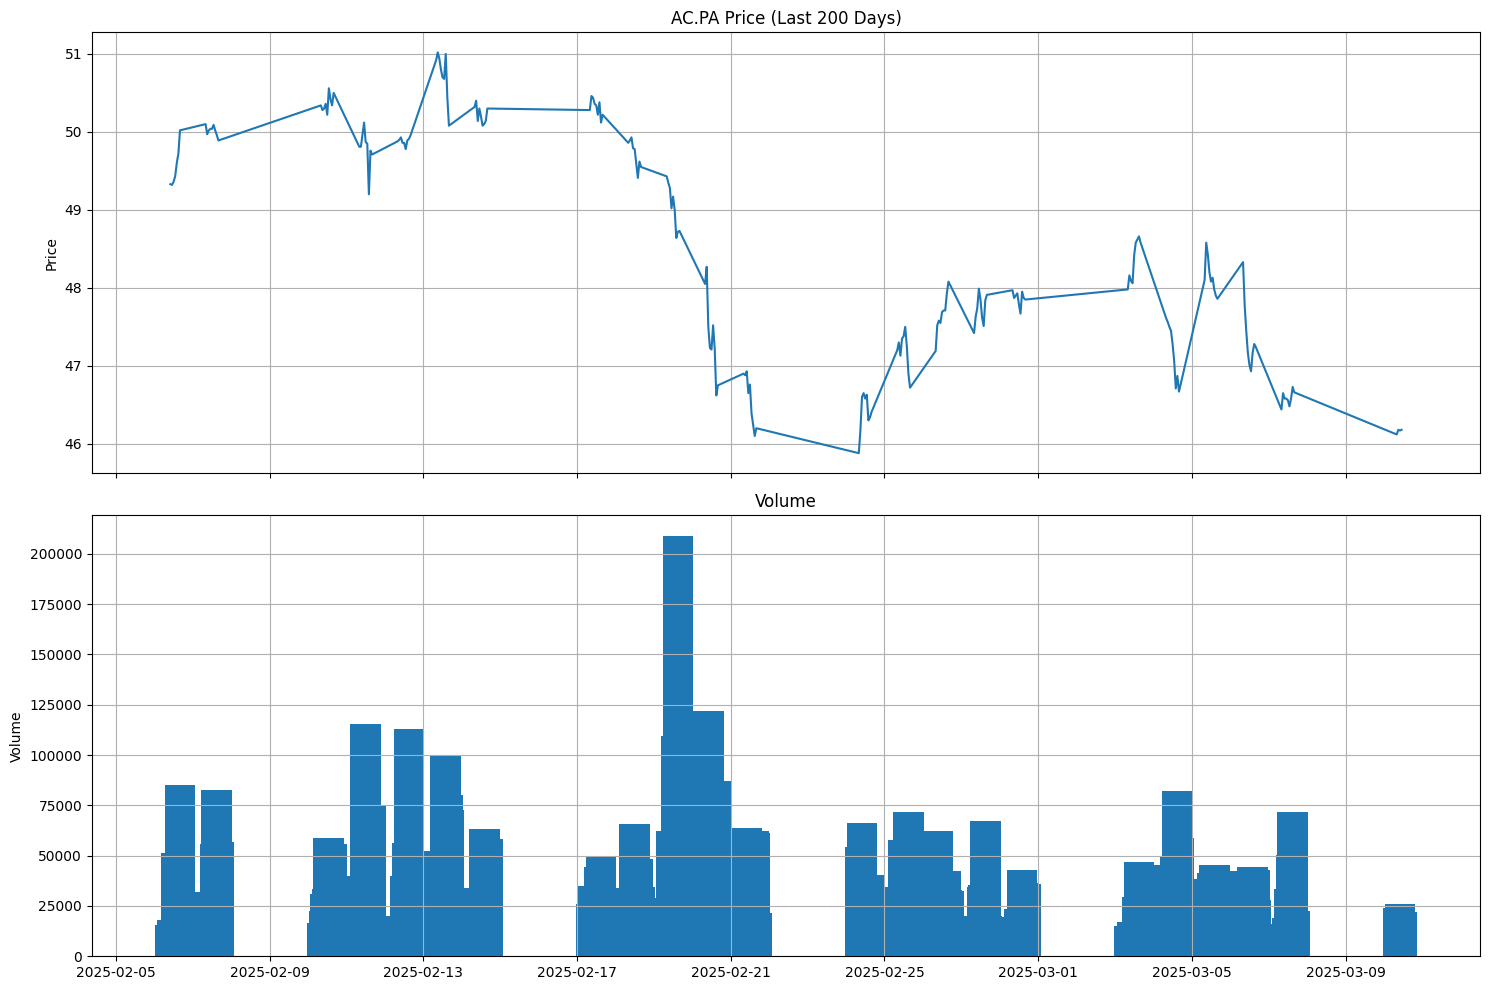

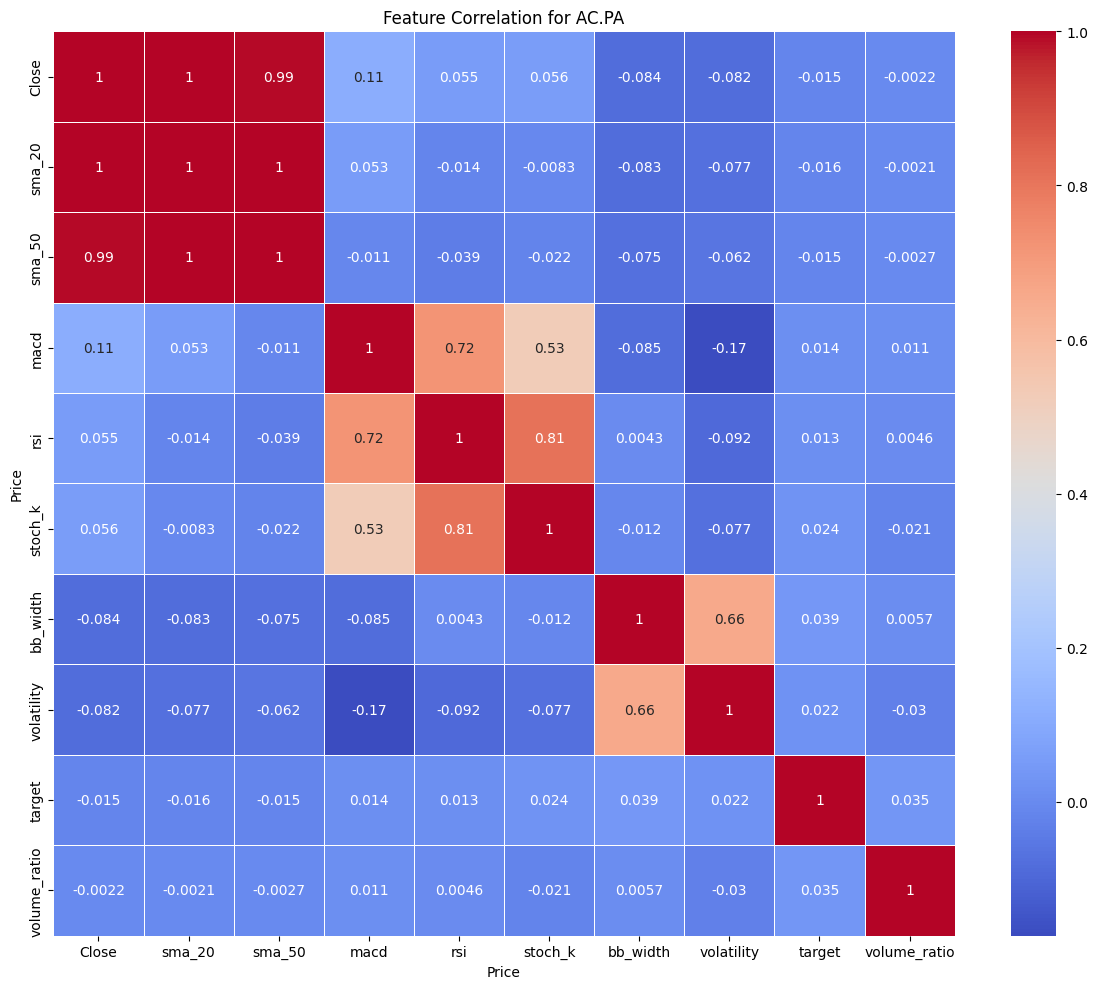

Target distribution:
target
1    0.533731
0    0.466269
Name: proportion, dtype: float64


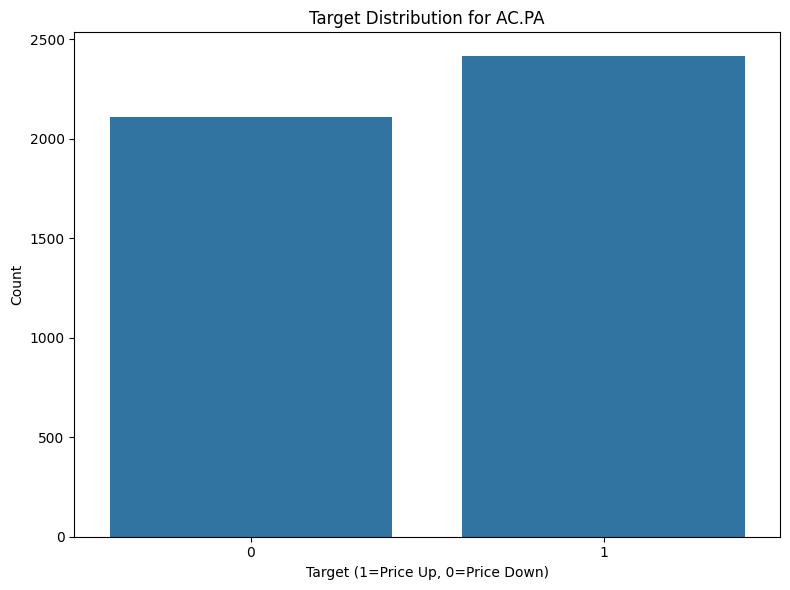


Feature data types:
sma_20: float64
sma_50: float64
ema_12: float64
ema_26: float64
macd: float64
macd_signal: float64
rsi: float64
bb_middle: float64
bb_std: float64
bb_upper: float64
bb_lower: float64
bb_width: float64
stoch_k: float64
stoch_d: float64
volatility: float64
volume_ratio: float64


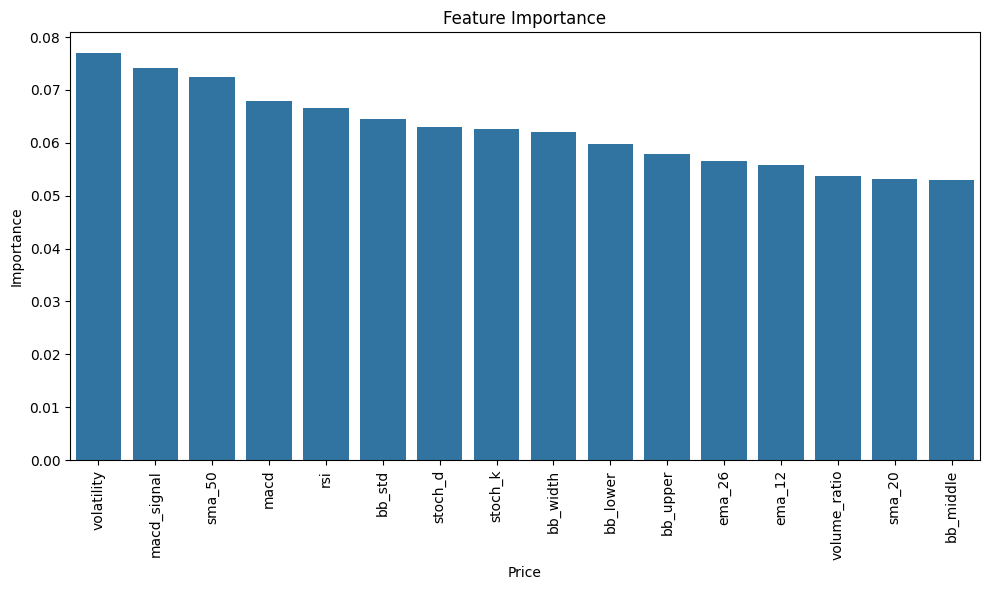

In [10]:
def explore_ticker(df, ticker):
    print(f"\nAnalysis for {ticker}")
    
    # Drop NaN values for analysis
    analysis_df = df.dropna()
    
    if len(analysis_df) < 50:  # Minimum data required for meaningful analysis
        print(f"Not enough data points for {ticker} after removing NaNs")
        return
    
    # Plot price and volume
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    
    # Get last 200 days or fewer if not available
    n_days = min(200, len(analysis_df))
    
    ax1.plot(analysis_df.index[-n_days:], analysis_df['Close'][-n_days:])
    ax1.set_title(f"{ticker} Price (Last {n_days} Days)")
    ax1.set_ylabel("Price")
    ax1.grid(True)
    
    if 'Volume' in analysis_df.columns:
        ax2.bar(analysis_df.index[-n_days:], analysis_df['Volume'][-n_days:])
        ax2.set_title("Volume")
        ax2.set_ylabel("Volume")
        ax2.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Ensure we have the required features
    required_features = ['Close', 'sma_20', 'sma_50', 'macd', 'rsi', 'stoch_k', 'bb_width', 'volatility', 'target']
    if 'volume_ratio' in analysis_df.columns:
        required_features.append('volume_ratio')
        
    available_features = [col for col in required_features if col in analysis_df.columns]
    
    # Feature correlations
    if len(available_features) > 1:  # Need at least 2 features for correlation
        corr = analysis_df[available_features].corr()
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(f"Feature Correlation for {ticker}")
        plt.tight_layout()
        plt.show()
    
    # Analyze distribution of target variable
    if 'target' in analysis_df.columns:
        target_dist = analysis_df['target'].value_counts(normalize=True)
        print(f"Target distribution:\n{target_dist}")
        
        # Visualize target distribution
        plt.figure(figsize=(8, 6))
        sns.countplot(x='target', data=analysis_df)
        plt.title(f"Target Distribution for {ticker}")
        plt.xlabel("Target (1=Price Up, 0=Price Down)")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
    
    # Check feature importance if we have enough features
    try:
        from sklearn.ensemble import RandomForestClassifier
        
        # Select features for model, excluding price and volume columns
        feature_cols = [col for col in analysis_df.columns 
                        if col not in ['Open', 'High', 'Low', 'Close', 'Volume', 'target', 'future_return', 'returns', 'Ticker']]
        
        # Make sure to only include numeric columns
        numeric_cols = []
        for col in feature_cols:
            if pd.api.types.is_numeric_dtype(analysis_df[col]):
                numeric_cols.append(col)
            else:
                print(f"Skipping non-numeric column: {col}")
        
        feature_cols = numeric_cols
        
        if len(feature_cols) < 2:
            print("Not enough numeric features for importance analysis")
            return
            
        X = analysis_df[feature_cols].fillna(0)
        y = analysis_df['target']
        
        # Print feature data types for debugging
        print("\nFeature data types:")
        for col in feature_cols:
            print(f"{col}: {X[col].dtype}")
        
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X, y)
        
        # Plot feature importance
        feature_imp = pd.DataFrame(model.feature_importances_, index=X.columns, columns=['Importance'])
        feature_imp = feature_imp.sort_values('Importance', ascending=False)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=feature_imp.index, y='Importance', data=feature_imp)
        plt.title('Feature Importance')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error in feature importance calculation: {e}")
        import traceback
        traceback.print_exc()

# Try running the analysis with error handling
if len(tickers) > 0:
    sample_ticker = tickers[0]
    print(f"Analyzing ticker: {sample_ticker}")
    try:
        explore_ticker(ticker_dfs[sample_ticker], sample_ticker)
    except Exception as e:
        print(f"Error exploring ticker {sample_ticker}: {e}")
        import traceback
        traceback.print_exc()
else:
    print("No tickers found in the dataset")

In [11]:
# Function to analyze all tickers in our dataset
def analyze_all_tickers():
    print(f"Analyzing all {len(tickers)} tickers in the dataset")
    
    # Create summary statistics for all tickers
    ticker_stats = []
    
    for ticker in tickers:
        try:
            df = ticker_dfs[ticker].copy().dropna()
            if len(df) < 30:  # Minimum data requirement
                continue
                
            # Calculate basic statistics
            stats = {
                'Ticker': ticker,
                'Avg_Close': df['Close'].mean(),
                'Std_Close': df['Close'].std(),
                'Avg_Return': df['returns'].mean() * 100,  # In percentage
                'Volatility': df['volatility'].mean() * 100,  # In percentage
                'Data_Points': len(df),
                'Target_Ratio': df['target'].mean() * 100  # Percentage of up days
            }
            
            if 'rsi' in df.columns:
                stats['Avg_RSI'] = df['rsi'].mean()
            
            if 'Volume' in df.columns:
                stats['Avg_Volume'] = df['Volume'].mean()
            
            ticker_stats.append(stats)
            
        except Exception as e:
            print(f"Error analyzing {ticker}: {e}")
    
    # Convert to DataFrame for easy analysis
    summary_df = pd.DataFrame(ticker_stats)
    
    if len(summary_df) > 0:
        # Sort by average return
        summary_df = summary_df.sort_values('Avg_Return', ascending=False)
        
        # Display top performers
        print("\nTop 5 performers by average return:")
        print(summary_df.head(5))
        
        # Display bottom performers
        print("\nBottom 5 performers by average return:")
        print(summary_df.tail(5))
        
        # Display tickers with highest target ratio (most likely to go up)
        print("\nTop 5 tickers by target ratio (most likely to go up):")
        print(summary_df.sort_values('Target_Ratio', ascending=False).head(5))
        
    else:
        print("No valid ticker statistics found")
        
    return summary_df

# Uncomment to run analysis on all tickers
summary_df = analyze_all_tickers()

Analyzing all 40 tickers in the dataset

Top 5 performers by average return:
    Ticker   Avg_Close  Std_Close  Avg_Return  Volatility  Data_Points  \
16  GLE.PA   24.510471   3.637077    0.017141    0.545866         4521   
31  SGO.PA   69.865040  13.349636    0.016410    0.467728         4521   
29  SAF.PA  182.748732  33.792618    0.015349    0.392474         4521   
17   HO.PA  145.919432  14.985138    0.014806    0.444805         4521   
12   EL.PA  197.057652  30.621256    0.012876    0.379040         4521   

    Target_Ratio    Avg_RSI     Avg_Volume  
16     52.864411  53.033978  171382.685025  
31     54.169432  53.131031   49127.217209  
29     53.594338  53.181010   27023.767750  
17     53.417386  52.354135   12112.861093  
12     52.267198  52.363582   19945.611590  

Bottom 5 performers by average return:
      Ticker   Avg_Close   Std_Close  Avg_Return  Volatility  Data_Points  \
37    VIV.PA    8.625949    2.243443   -0.012111    0.491756         4521   
34    TEP.PA  

Training model for AC.PA
Training with 3600 sequences, testing with 901 sequences


C:\Users\Yassine Hachmi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.5102 - loss: 0.7559 - val_accuracy: 0.5264 - val_loss: 0.6931
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5513 - loss: 0.7110 - val_accuracy: 0.5431 - val_loss: 0.7005
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5422 - loss: 0.7035 - val_accuracy: 0.4750 - val_loss: 0.7036
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5732 - loss: 0.6845 - val_accuracy: 0.4861 - val_loss: 0.7152
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5803 - loss: 0.6839 - val_accuracy: 0.5181 - val_loss: 0.7326
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6110 - loss: 0.6591 - val_accuracy: 0.5264 - val_loss: 0.7690
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6106 - loss: 0.6669 - val_accuracy: 0.4444 - val_loss: 0.7974
Epoch 8/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6116 - loss: 0.6670 - val_accuracy: 0.

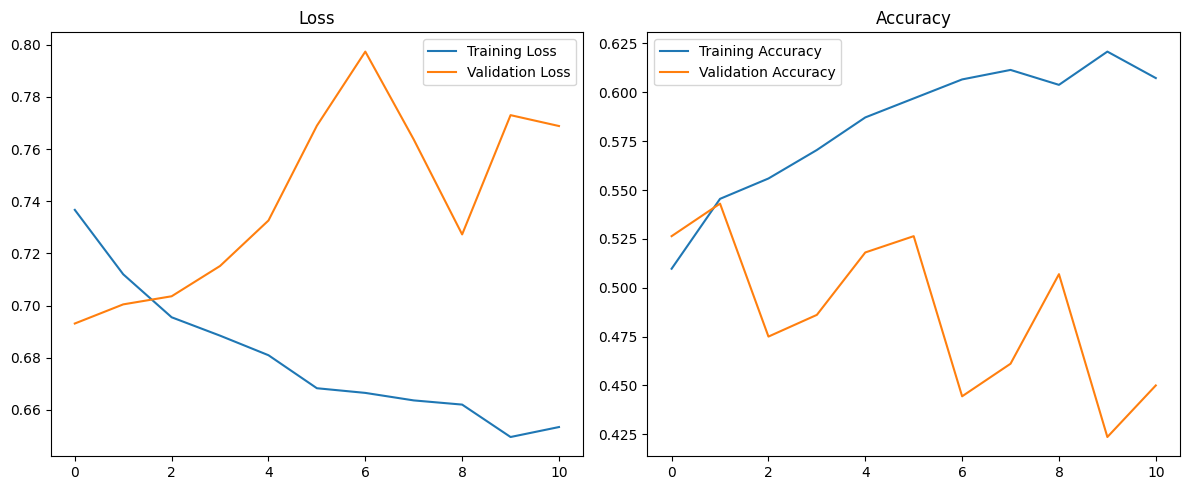

Training model for ACA.PA
Training with 3600 sequences, testing with 901 sequences
Epoch 1/100


C:\Users\Yassine Hachmi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.5143 - loss: 0.7563 - val_accuracy: 0.5556 - val_loss: 0.6907
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5429 - loss: 0.6973 - val_accuracy: 0.5681 - val_loss: 0.6892
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5428 - loss: 0.6968 - val_accuracy: 0.4611 - val_loss: 0.7046
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5560 - loss: 0.6937 - val_accuracy: 0.5556 - val_loss: 0.6936
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5589 - loss: 0.6936 - val_accuracy: 0.5111 - val_loss: 0.7111
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5852 - loss: 0.6779 - val_accuracy: 0.5736 - val_loss: 0.6935
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5993 - loss: 0.6676 - val_accuracy: 0.5569 - val_loss: 0.6986
Epoch 8/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6030 - loss: 0.6662 - val_accuracy: 0.4972 - val_l

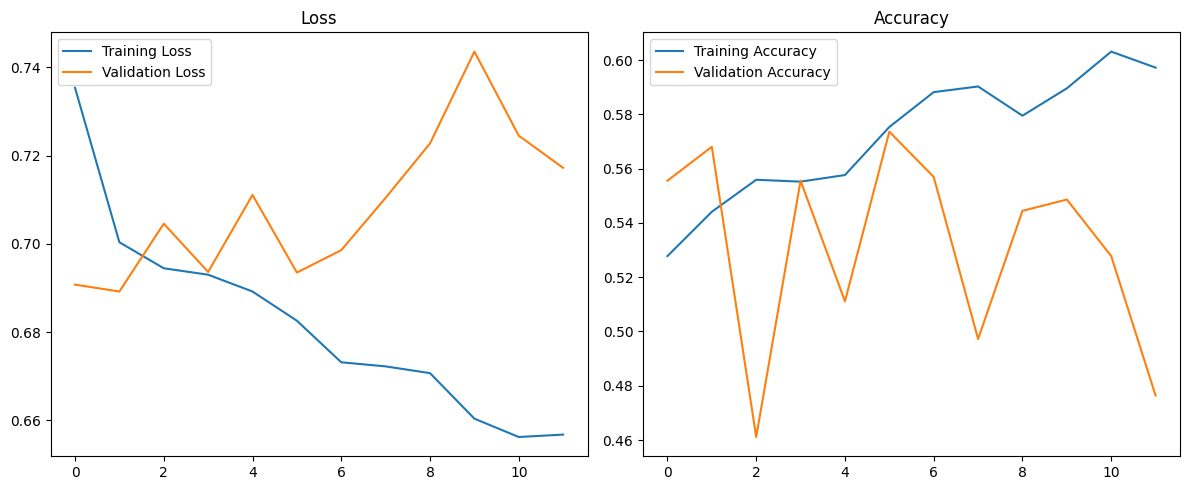

Training model for AI.PA
Training with 3600 sequences, testing with 901 sequences
Epoch 1/100


C:\Users\Yassine Hachmi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.5302 - loss: 0.7566 - val_accuracy: 0.5556 - val_loss: 0.6898
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5138 - loss: 0.7334 - val_accuracy: 0.4583 - val_loss: 0.7057
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5171 - loss: 0.7147 - val_accuracy: 0.5556 - val_loss: 0.6983
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5669 - loss: 0.6862 - val_accuracy: 0.5472 - val_loss: 0.7076
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.5458 - loss: 0.6959 - val_accuracy: 0.5292 - val_loss: 0.6951
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5761 - loss: 0.6758 - val_accuracy: 0.5514 - val_loss: 0.7106
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5614 - loss: 0.6834 - val_accuracy: 0.5153 - val_loss: 0.7082
Epoch 8/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.5952 - loss: 0.6678 - val_accuracy: 0.4569 - val_l

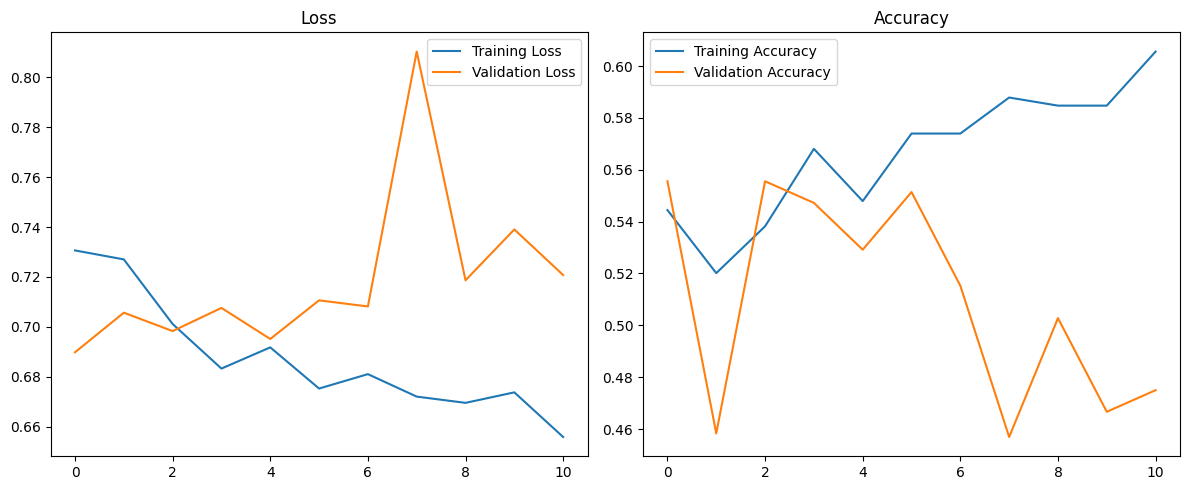

Successfully trained models for 3 out of 3 tickers


In [12]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

def prepare_sequences(data, seq_length=20):
    """Convert data to sequences for LSTM."""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length, -1])  # Target is the last column
    return np.array(X), np.array(y)

def build_model(ticker, test_size=0.2):
    df = ticker_dfs[ticker].copy()
    
    # Drop rows with NaN values
    df = df.dropna()
    
    if len(df) < 50:
        print(f"Not enough data for {ticker} after removing NaN values. Skipping.")
        return None, None, None
    
    # Prepare features and target
    # Adjust column filter based on your dataframe structure
    feature_cols = [col for col in df.columns if col not in ['Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'target', 'Value', 'future_return', 'returns']]
    
    # Ensure all feature columns are numeric
    valid_features = []
    for col in feature_cols:
        if pd.api.types.is_numeric_dtype(df[col]):
            valid_features.append(col)
        else:
            print(f"Skipping non-numeric feature: {col}")
    
    if len(valid_features) < 3:
        print(f"Not enough valid features for {ticker}. Skipping.")
        return None, None, None
        
    X = df[valid_features].values
    y = df['target'].values
    
    # Scale features
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Add target as last column for sequence preparation
    data = np.column_stack((X_scaled, y))
    
    # Prepare sequences
    X_seq, y_seq = prepare_sequences(data, seq_length=20)
    
    if len(X_seq) < 50:  # Check if we have enough sequences
        print(f"Not enough sequences for {ticker}. Skipping.")
        return None, None, None
    
    # Time-based split (not random)
    split_idx = int(len(X_seq) * (1 - test_size))
    X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
    y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]
    
    print(f"Training with {len(X_train)} sequences, testing with {len(X_test)} sequences")
    
    # Build the LSTM model
    model = Sequential([
        LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2] - 1)),
        BatchNormalization(),
        Dropout(0.2),
        LSTM(50),
        BatchNormalization(),
        Dropout(0.2),
        Dense(20, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    # Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    # Train the model
    history = model.fit(
        X_train[:, :, :-1],  # Exclude target from features
        y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Evaluate on test set
    y_pred_proba = model.predict(X_test[:, :, :-1])
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    print(f"Model performance for {ticker}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)
    
    # Plot training history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return model, scaler, valid_features

# Train model for selected tickers
models = {}
# You can adjust the number of tickers to train on
ticker_subset = tickers[:3]  # Start with just 3 tickers

for ticker in ticker_subset:
    print(f"Training model for {ticker}")
    model, scaler, features = build_model(ticker)
    if model is not None:
        models[ticker] = {
            'model': model,
            'scaler': scaler,
            'features': features
        }

# Summary of trained models
print(f"Successfully trained models for {len(models)} out of {len(ticker_subset)} tickers")